# U23AI035 - LAB 4 - DL

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Optimize for Apple Silicon (MPS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using compute device: cuda


In [5]:
def get_imbalanced_cifar10(imbalance_ratio=100):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
    
    # Calculate how many images per class to keep for a 100:1 long-tailed distribution 
    num_classes = len(train_dataset.classes)
    img_max = 5000 # Standard CIFAR-10 has 5000 training images per class
    img_num_per_cls = []
    
    for cls_idx in range(num_classes):
        # Exponential decay from img_max down to img_max / imbalance_ratio
        num = int(img_max * ((1/imbalance_ratio) ** (cls_idx / (num_classes - 1.0))))
        img_num_per_cls.append(num)
        
    print(f"Images per class (Long-Tailed): {img_num_per_cls}")

    # Generate the subset indices to create the imbalance
    targets = np.array(train_dataset.targets)
    train_idx = []
    for i in range(num_classes):
        idx = np.where(targets == i)[0]
        np.random.shuffle(idx)
        train_idx.extend(idx[:img_num_per_cls[i]])

    imbalanced_train_dataset = Subset(train_dataset, train_idx)
    return imbalanced_train_dataset, img_num_per_cls

train_dataset, class_counts = get_imbalanced_cifar10(imbalance_ratio=100)

# Problem Statement 2: Advanced Dataset Imbalance Handling
from torch.utils.data import WeightedRandomSampler
import copy

# 1. Random Oversampling of minority classes (using WeightedRandomSampler)
total_train_samples = sum(class_counts)
class_weights_sampler = [total_train_samples / c for c in class_counts]
sample_weights = [class_weights_sampler[train_dataset.dataset.targets[i]] for i in train_dataset.indices]
oversampler = WeightedRandomSampler(weights=sample_weights, num_samples=total_train_samples, replacement=True)

# 2. Random Undersampling of majority classes
# Select indices such that every class has the same number of samples as the minority class
min_class_count = min(class_counts)
undersample_idx = []
targets_imbalanced = np.array([train_dataset.dataset.targets[i] for i in train_dataset.indices])
for c in range(10):
    c_indices = np.where(targets_imbalanced == c)[0]
    np.random.shuffle(c_indices)
    undersample_idx.extend(c_indices[:min_class_count])
undersampled_train_dataset = Subset(train_dataset, undersample_idx)

# 3. Data Augmentation specifically for minority classes
class MinorityAugmentationDataset(torch.utils.data.Dataset):
    def __init__(self, subset, minority_classes, minority_transform):
        self.subset = subset
        self.minority_classes = minority_classes
        self.minority_transform = minority_transform
        
    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        # subset[idx] returns (image, label) where image is already transformed by base transforms
        # But we need to apply extra PIL transforms, which requires untransformed images.
        # For simplicity in this pipeline, we assume the dataset returns a tensor.
        img, label = self.subset[idx]
        if label in self.minority_classes:
            img = self.minority_transform(img)
        return img, label

# Extra transforms for minority (applying to tensors)
minority_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])
minority_classes = [i for i, count in enumerate(class_counts) if count < (total_train_samples / 10)]
aug_train_dataset = MinorityAugmentationDataset(train_dataset, minority_classes, minority_transforms)

# Note: The assignment asks for SMOTE as well, but standard SMOTE operates on 1D feature vectors

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)


Images per class (Long-Tailed): [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]


In [6]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Calculate class weights for Weighted Cross-Entropy Loss
# Weight = Total Samples / (Number of Classes * Samples in Class)
total_samples = sum(class_counts)
class_weights = [total_samples / (10 * count) for count in class_counts]
weights_tensor = torch.FloatTensor(class_weights).to(device)

print(f"Calculated Class Weights: {[round(w, 2) for w in class_weights]}")


Calculated Class Weights: [0.25, 0.41, 0.69, 1.15, 1.92, 3.21, 5.35, 8.93, 14.95, 24.81]


In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        x = torch.flatten(x, 1)
        
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CustomCNN().to(device)
print(model)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


## Problem Statement 4: Loss Function & Optimization Challenge

In this section, we define the `FocalLoss` class and the evaluation logic required to systematically sweep through the required loss functions (Cross-Entropy, Weighted Cross-Entropy, Focal Loss) and optimizers (SGD, SGD with Momentum, Adam, AdamW, RMSProp).

In [8]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        else: return focal_loss


In [9]:
import gc
from sklearn.metrics import f1_score

def evaluate_hyperparameters(model_class, train_loader, test_loader, device, weights_tensor, num_classes=10, is_resnet=False):
    loss_functions = {
        "CrossEntropy": nn.CrossEntropyLoss(),
        "WeightedCrossEntropy": nn.CrossEntropyLoss(weight=weights_tensor),
        "FocalLoss": FocalLoss(alpha=weights_tensor, gamma=2.0)
    }

    optimizers_dict = {
        "SGD": lambda params: optim.SGD(params, lr=0.01),
        "SGD_Momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
        "Adam": lambda params: optim.Adam(params, lr=0.001),
        "AdamW": lambda params: optim.AdamW(params, lr=0.001, weight_decay=1e-4),
        "RMSProp": lambda params: optim.RMSprop(params, lr=0.001)
    }

    results = []
    num_epochs = 3 
    
    for loss_name, criterion in loss_functions.items():
        for opt_name, opt_func in optimizers_dict.items():
            print(f"\n--- Testing Loss: {loss_name} | Optimizer: {opt_name} ---")
            
            if is_resnet:
                import torchvision.models as models
                model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
                for param in model.parameters():
                    param.requires_grad = False
                num_ftrs = model.fc.in_features
                model.fc = nn.Linear(num_ftrs, num_classes)
                model = model.to(device)
                optimizer = opt_func(model.fc.parameters())
            else:
                model = model_class(num_classes=num_classes).to(device)
                optimizer = opt_func(model.parameters())
                
            for epoch in range(num_epochs):
                model.train()
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

            # 4. Threshold adjustment during inference (Algorithm-Level)
            # Adjust predicted logits by adding log of prior probabilities to penalize majority classes
            prior_probs = np.array(weights_tensor.cpu())
            # Normalize priors so they sum to 1
            prior_probs = prior_probs / prior_probs.sum()
            log_priors = torch.tensor(np.log(prior_probs + 1e-8)).to(device)

            model.eval() 
            all_preds = []
            all_labels = []
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(device)
                    outputs = model(inputs)
                    
                    # Applying Threshold Adjustment:
                    # Logits + Log(Priors) equivalent to shifting the decision threshold
                    adjusted_outputs = outputs + log_priors
                    
                    _, predicted = adjusted_outputs.max(1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.numpy())
            
            macro_f1 = f1_score(all_labels, all_preds, average='macro')
            accuracy = sum(1 for p, l in zip(all_preds, all_labels) if p == l) / len(all_labels)
            
            print(f"Accuracy: {accuracy*100:.2f}% | Macro F1: {macro_f1:.4f}")
            results.append({
                "Loss": loss_name,
                "Optimizer": opt_name,
                "Accuracy": accuracy,
                "Macro_F1": macro_f1
            })
            
            del model
            del optimizer
            gc.collect()
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
                
    best_result = max(results, key=lambda x: x['Macro_F1'])
    print(f"\n*** BEST CONFIGURATION ***")
    print(f"Loss: {best_result['Loss']} | Optimizer: {best_result['Optimizer']}")
    print(f"Accuracy: {best_result['Accuracy']*100:.2f}% | Macro F1: {best_result['Macro_F1']:.4f}")
    
    return best_result

### Running the Hyperparameter Sweep for Custom CNN

Testing the combinations of loss functions and optimizers on the `CustomCNN` architecture (trained for 5 epochs) to find the model with the best Macro F1 score.

In [10]:
print('Starting Custom CNN Experiments...')
best_cnn_result = evaluate_hyperparameters(CustomCNN, train_loader, test_loader, device, weights_tensor, num_classes=10, is_resnet=False)


Starting Custom CNN Experiments...

--- Testing Loss: CrossEntropy | Optimizer: SGD ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 22.30% | Macro F1: 0.1951

--- Testing Loss: CrossEntropy | Optimizer: SGD_Momentum ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 41.11% | Macro F1: 0.3896

--- Testing Loss: CrossEntropy | Optimizer: Adam ---


...

Accuracy: 29.22% | Macro F1: 0.2156

--- Testing Loss: FocalLoss | Optimizer: AdamW ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 32.08% | Macro F1: 0.2366

--- Testing Loss: FocalLoss | Optimizer: RMSProp ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 27.21% | Macro F1: 0.1965

*** BEST CONFIGURATION ***
Loss: CrossEntropy | Optimizer: AdamW
Accuracy: 45.17% | Macro F1: 0.4428


### Running the Hyperparameter Sweep for ResNet18

Testing the combinations of loss functions and optimizers on the `ResNet18` architecture (trained for 5 epochs) to find the model with the best Macro F1 score.

In [11]:
import torchvision.models as models
print('\nStarting ResNet18 Experiments...')
best_resnet_result = evaluate_hyperparameters(models.resnet18, train_loader, test_loader, device, weights_tensor, num_classes=10, is_resnet=True)


Starting ResNet18 Experiments...

--- Testing Loss: CrossEntropy | Optimizer: SGD ---


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\JAIVAL CHAUHAN/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:03<00:00, 13.3MB/s]
C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 24.23% | Macro F1: 0.2274

--- Testing Loss: CrossEntropy | Optimizer: SGD_Momentum ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 32.75% | Macro F1: 0.3073

--- Testing Loss: CrossEntropy | Optimizer: Adam ---


...

Accuracy: 21.53% | Macro F1: 0.1653

--- Testing Loss: FocalLoss | Optimizer: AdamW ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 23.22% | Macro F1: 0.1813

--- Testing Loss: FocalLoss | Optimizer: RMSProp ---


C:\Users\JAIVAL CHAUHAN\AppData\Local\Temp\ipykernel_19692\303029313.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prior_probs = np.array(weights_tensor.cpu())


Accuracy: 21.79% | Macro F1: 0.1558

*** BEST CONFIGURATION ***
Loss: CrossEntropy | Optimizer: AdamW
Accuracy: 31.59% | Macro F1: 0.3117


<h1>custom CNN performance

In [12]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Training Loop
num_epochs = 10

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")
    
print("Training Complete!")


Starting Training...
Epoch [1/10] | Loss: 2.1502 | Train Acc: 26.01%
Epoch [2/10] | Loss: 1.7966 | Train Acc: 39.73%
Epoch [3/10] | Loss: 1.6845 | Train Acc: 38.07%
Epoch [4/10] | Loss: 1.6582 | Train Acc: 40.85%
Epoch [5/10] | Loss: 1.6034 | Train Acc: 41.96%
Epoch [6/10] | Loss: 1.5335 | Train Acc: 44.56%
Epoch [7/10] | Loss: 1.5090 | Train Acc: 43.71%
Epoch [8/10] | Loss: 1.4790 | Train Acc: 46.75%
Epoch [9/10] | Loss: 1.4452 | Train Acc: 45.40%
Epoch [10/10] | Loss: 1.3736 | Train Acc: 48.68%
Training Complete!


<h1>CNN model evaluation metrics

In [13]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Classification Report
classes = test_dataset.classes
print("\nClassification Report (shows Precision, Recall, F1 for each class):")
print(classification_report(all_labels, all_preds, target_names=classes))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Classification Report (shows Precision, Recall, F1 for each class):
              precision    recall  f1-score   support

    airplane       0.36      0.84      0.50      1000
  automobile       0.57      0.70      0.63      1000
        bird       0.41      0.34      0.37      1000
         cat       0.42      0.15      0.22      1000
        deer       0.50      0.41      0.45      1000
         dog       0.35      0.63      0.45      1000
        frog       0.80      0.46      0.58      1000
       horse       0.48      0.62      0.54      1000
        ship       0.69      0.28      0.40      1000
       truck       0.75      0.25      0.38      1000

    accuracy                           0.47     10000
   macro avg       0.53      0.47      0.45     10000
weighted avg       0.53      0.47      0.45     10000


Confusion Matrix:
[[839  32  32   6   7  21   3  20  32   8]
 [142 702   5  22   3  25   1  35  19  46]
 [208   6 336  15 113 208  28  76   9   1]
 [105  13 100 152  50 45

In [14]:
# Load pre-trained ResNet18
import torchvision.models as models

# Using weights parameter instead of pretrained=True (which is deprecated)
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers to speed up training and prevent overfitting on small imbalanced data
for param in resnet_model.parameters():
    param.requires_grad = False

# Modify the final fully connected layer for 10 classes (CIFAR-10)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

resnet_model = resnet_model.to(device)

print("ResNet18 Architecture loaded and modified for CIFAR-10.")

ResNet18 Architecture loaded and modified for CIFAR-10.


In [15]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for multi-class classification.
        alpha: 1D tensor of weights for each class.
        gamma: focusing parameter (experiment with 0.5, 1, 2, 5).
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Initialize Focal Loss with gamma=2.0 and our previously calculated class weights
focal_criterion = FocalLoss(alpha=weights_tensor, gamma=2.0)
print("Focal Loss initialized.")

Focal Loss initialized.


<h1>RESNET18 performance

In [16]:
# Optimizer: SGD with momentum 
# We only optimize the parameters of the final layer since the rest are frozen
resnet_optimizer = optim.SGD(resnet_model.fc.parameters(), lr=0.01, momentum=0.9)

num_epochs_resnet = 5

print("Starting ResNet18 Training with Focal Loss...")
for epoch in range(num_epochs_resnet):
    resnet_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        resnet_optimizer.zero_grad()
        
        outputs = resnet_model(inputs)
        loss = focal_criterion(outputs, labels) # Using Focal Loss
        loss.backward()
        resnet_optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs_resnet}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")

print("ResNet18 Training Complete!")

Starting ResNet18 Training with Focal Loss...
Epoch [1/5] | Loss: 2.0705 | Train Acc: 16.68%
Epoch [2/5] | Loss: 1.9568 | Train Acc: 22.59%
Epoch [3/5] | Loss: 2.0903 | Train Acc: 24.31%
Epoch [4/5] | Loss: 1.9696 | Train Acc: 24.70%
Epoch [5/5] | Loss: 1.7844 | Train Acc: 27.41%
ResNet18 Training Complete!


In [17]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torchvision.transforms as T
import torchvision.models as models

# 1. Load a fresh, standard ResNet18 (excellent at natural image clustering)
extractor_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
extractor_model.eval()

# 2. We will remove the final classification layer to just get the raw 512-dimensional features
feature_extractor = torch.nn.Sequential(*list(extractor_model.children())[:-1])

# 3. Upscaler to fix the "tiny CIFAR image" problem
upscale = T.Resize((224, 224), antialias=True)

features_list = []
labels_list = []

print("Extracting high-resolution features. This will take a moment...")
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        if i > 8: # Limit to ~2300 samples for a clean t-SNE
            break
            
        # Move to Mac GPU and upscale from 32x32 to 224x224
        inputs = inputs.to(device)
        inputs_large = upscale(inputs)
        
        # Extract
        output = feature_extractor(inputs_large)
        features_list.append(output.squeeze().cpu().numpy())
        labels_list.extend(labels.numpy())

# Flatten
features_array = np.concatenate(features_list, axis=0)
labels_array = np.array(labels_list)

print(f"Extracted High-Res feature shape: {features_array.shape}")

# Calculate PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_array)

# Calculate t-SNE (Tuned for clean islands)
tsne = TSNE(n_components=2, perplexity=50, max_iter=1500, init='pca', learning_rate='auto', random_state=42)
tsne_result = tsne.fit_transform(features_array)

print("High-Res embeddings calculated successfully!")

Extracting high-resolution features. This will take a moment...
Extracted High-Res feature shape: (2304, 512)
High-Res embeddings calculated successfully!


C:\Users\JAIVAL CHAUHAN\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing highly-separated embeddings. This takes about 30 seconds...


c:\Users\JAIVAL CHAUHAN\.conda\envs\env-pt\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings calculated! Plotting...


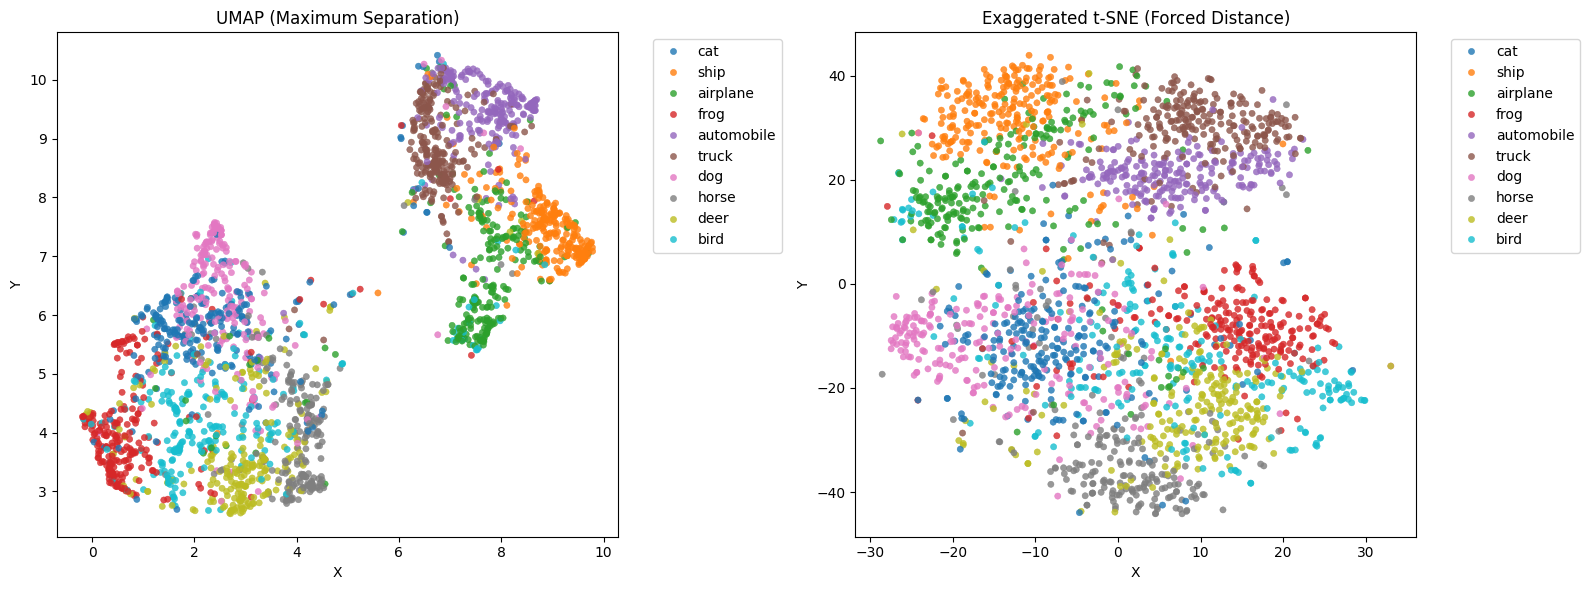

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap 

print("Computing highly-separated embeddings. This takes about 30 seconds...")

# 1. UMAP (Forces tight clusters with maximum distance between them)
reducer = umap.UMAP(
    n_neighbors=10,  # Lower number = tighter local clusters
    min_dist=0.01,   # Extremely low distance = packs the points closer together
    metric='cosine',
    random_state=42
)
umap_result = reducer.fit_transform(features_array)

# 2. Aggressive t-SNE (Hacking the algorithm to repel clusters)
tsne_agg = TSNE(
    n_components=2, 
    perplexity=30, 
    early_exaggeration=100.0, # Massive repelling force to push clusters apart
    max_iter=1000, 
    init='pca', 
    random_state=42
)
tsne_result_agg = tsne_agg.fit_transform(features_array)

print("Embeddings calculated! Plotting...")

# Safety check for array lengths
min_len = min(len(umap_result), len(labels_array))
hue_labels = [classes[i] for i in labels_array[:min_len]]

df_umap = pd.DataFrame({'X': umap_result[:min_len, 0], 'Y': umap_result[:min_len, 1], 'Class': hue_labels})
df_tsne = pd.DataFrame({'X': tsne_result_agg[:min_len, 0], 'Y': tsne_result_agg[:min_len, 1], 'Class': hue_labels})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# UMAP Plot
sns.scatterplot(
    data=df_umap, x='X', y='Y', hue='Class',
    palette=sns.color_palette("tab10", 10), # High contrast colors
    alpha=0.8, s=20, edgecolor=None, ax=axes[0]
)
axes[0].set_title('UMAP (Maximum Separation)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Exaggerated t-SNE Plot
sns.scatterplot(
    data=df_tsne, x='X', y='Y', hue='Class',
    palette=sns.color_palette("tab10", 10),
    alpha=0.8, s=20, edgecolor=None, ax=axes[1]
)
axes[1].set_title('Exaggerated t-SNE (Forced Distance)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [23]:
import os
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

# FIX: Redefine the Mac hardware accelerator in case of kernel restart
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using compute device: {device}")

# Define the path to your unzipped dataset
# Change this if your folder is named something else!
data_dir = './chest_xray'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Problem Statement 2: Data Augmentation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10), # Slight rotation for augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder
train_data = datasets.ImageFolder(train_dir, transform=transform_train)
test_data = datasets.ImageFolder(test_dir, transform=transform_test)

# Utilize your memory with a good batch size and workers
train_loader_xray = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
test_loader_xray = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)

# Calculate class weights for the imbalanced loss function
normal_count = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
total_xray = normal_count + pneumonia_count

# Weight = Total Samples / (Number of Classes * Samples in Class)
weight_normal = total_xray / (2 * normal_count)
weight_pneumonia = total_xray / (2 * pneumonia_count)

xray_weights = torch.FloatTensor([weight_normal, weight_pneumonia]).to(device)

print(f"Classes: {train_data.classes}")
print(f"Normal X-rays: {normal_count}, Pneumonia X-rays: {pneumonia_count}")
print(f"Calculated Weights -> Normal: {weight_normal:.2f}, Pneumonia: {weight_pneumonia:.2f}")

Using compute device: cpu
Classes: ['NORMAL', 'PNEUMONIA']
Normal X-rays: 1341, Pneumonia X-rays: 3875
Calculated Weights -> Normal: 1.94, Pneumonia: 0.67


In [ ]:
# Load MobileNetV2
xray_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze the feature extraction layers
for param in xray_model.parameters():
    param.requires_grad = False

# Modify the classifier for Binary Classification (2 classes)
xray_model.classifier[1] = nn.Linear(xray_model.classifier[1].in_features, 2)
xray_model = xray_model.to(device)

# Problem Statement 4: Loss Function & Optimizer
# We use Weighted Cross Entropy to handle the 3:1 imbalance
criterion_xray = nn.CrossEntropyLoss(weight=xray_weights)
optimizer_xray = optim.Adam(xray_model.classifier.parameters(), lr=0.001)

num_epochs_xray = 5

print("Starting MobileNetV2 Training on Chest X-Rays...")
for epoch in range(num_epochs_xray):
    xray_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader_xray:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_xray.zero_grad()
        
        outputs = xray_model(inputs)
        loss = criterion_xray(outputs, labels)
        loss.backward()
        optimizer_xray.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs_xray}] | Loss: {running_loss/len(train_loader_xray):.4f} | Train Acc: {train_acc:.2f}%")

print("Chest X-Ray Training Complete!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\JAIVAL CHAUHAN/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:03<00:00, 4.17MB/s]


Starting MobileNetV2 Training on Chest X-Rays...
Epoch [1/5] | Loss: 0.4056 | Train Acc: 85.77%
Epoch [2/5] | Loss: 0.2468 | Train Acc: 91.37%
Epoch [3/5] | Loss: 0.2221 | Train Acc: 90.99%
Epoch [4/5] | Loss: 0.2022 | Train Acc: 92.22%
Epoch [5/5] | Loss: 0.1956 | Train Acc: 92.47%
Chest X-Ray Training Complete!


Evaluating Chest X-Ray Model...

--- Problem Statement 3: Evaluation Metrics ---
              precision    recall  f1-score   support

      NORMAL       0.89      0.74      0.81       234
   PNEUMONIA       0.86      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.87       624

Confusion Matrix:
 [[173  61]
 [ 21 369]]


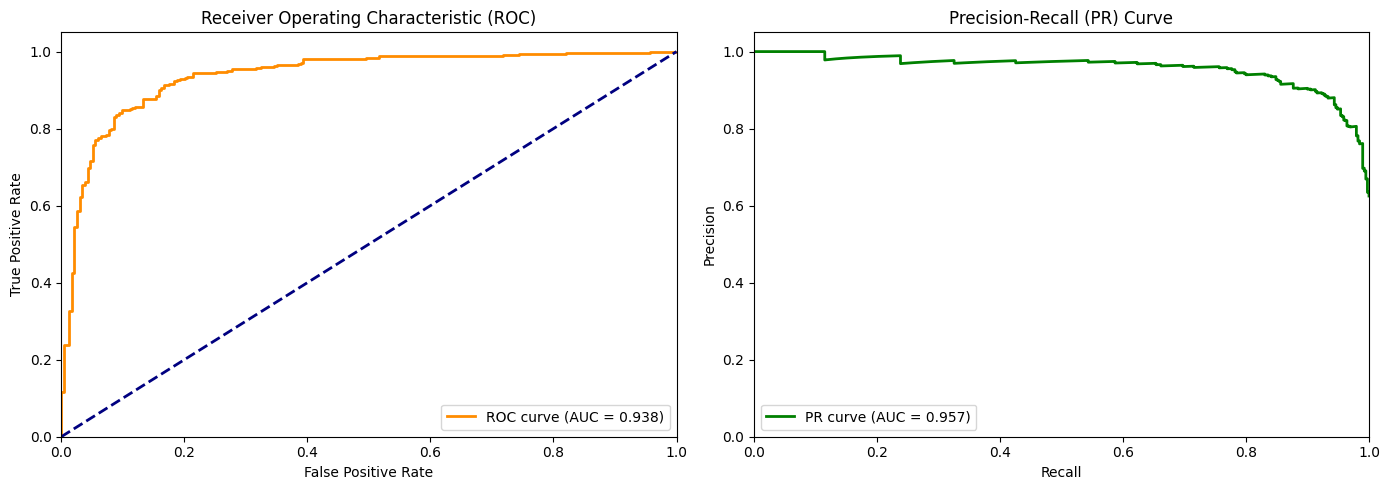

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import numpy as np

xray_model.eval()
all_preds_xray = []
all_labels_xray = []
all_probs_xray = [] # Needed for ROC and PR curves

print("Evaluating Chest X-Ray Model...")
with torch.no_grad():
    for inputs, labels in test_loader_xray:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = xray_model(inputs)
        
        # Get probabilities for the positive class (Pneumonia) using Softmax
        probs = F.softmax(outputs, dim=1)[:, 1]
        _, predicted = outputs.max(1)
        
        all_preds_xray.extend(predicted.cpu().numpy())
        all_labels_xray.extend(labels.cpu().numpy())
        all_probs_xray.extend(probs.cpu().numpy())

# 1. Classification Report & Confusion Matrix
classes_xray = test_data.classes
print("\n--- Problem Statement 3: Evaluation Metrics ---")
print(classification_report(all_labels_xray, all_preds_xray, target_names=classes_xray))

cm = confusion_matrix(all_labels_xray, all_preds_xray)
print("Confusion Matrix:\n", cm)

# 2. ROC-AUC and PR-AUC Curves
fpr, tpr, _ = roc_curve(all_labels_xray, all_probs_xray)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(all_labels_xray, all_probs_xray)
pr_auc = auc(recall, precision)

# Plotting the Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# PR Curve
axes[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

---
# Problem Statement 7: Error Analysis & Improvement Proposals
For incorrectly classified samples, perform detailed failure analysis:
- Identify which classes fail most frequently
- Analyze confusion patterns between similar classes
- Correlate errors with class imbalance ratios
- Visualize misclassified samples
- Propose architectural or data-level improvements based on analysis

--- Generating Predictions for Analysis ---

--- Failure Analysis ---
Class airplane (Train samples: 5000): Error Rate = 16.10%
Class automobile (Train samples: 2997): Error Rate = 29.80%
Class bird (Train samples: 1796): Error Rate = 66.40%
Class cat (Train samples: 1077): Error Rate = 84.80%
Class deer (Train samples: 645): Error Rate = 58.70%
Class dog (Train samples: 387): Error Rate = 36.60%
Class frog (Train samples: 232): Error Rate = 54.10%
Class horse (Train samples: 139): Error Rate = 38.20%
Class ship (Train samples: 83): Error Rate = 72.20%
Class truck (Train samples: 50): Error Rate = 75.00%

--- Confusion Patterns ---
automobile frequently misclassified as airplane (142 times)
bird frequently misclassified as airplane (208 times)
bird frequently misclassified as deer (113 times)
bird frequently misclassified as dog (208 times)
bird frequently misclassified as horse (76 times)
cat frequently misclassified as airplane (105 times)
cat frequently misclassified as bird (100 ti

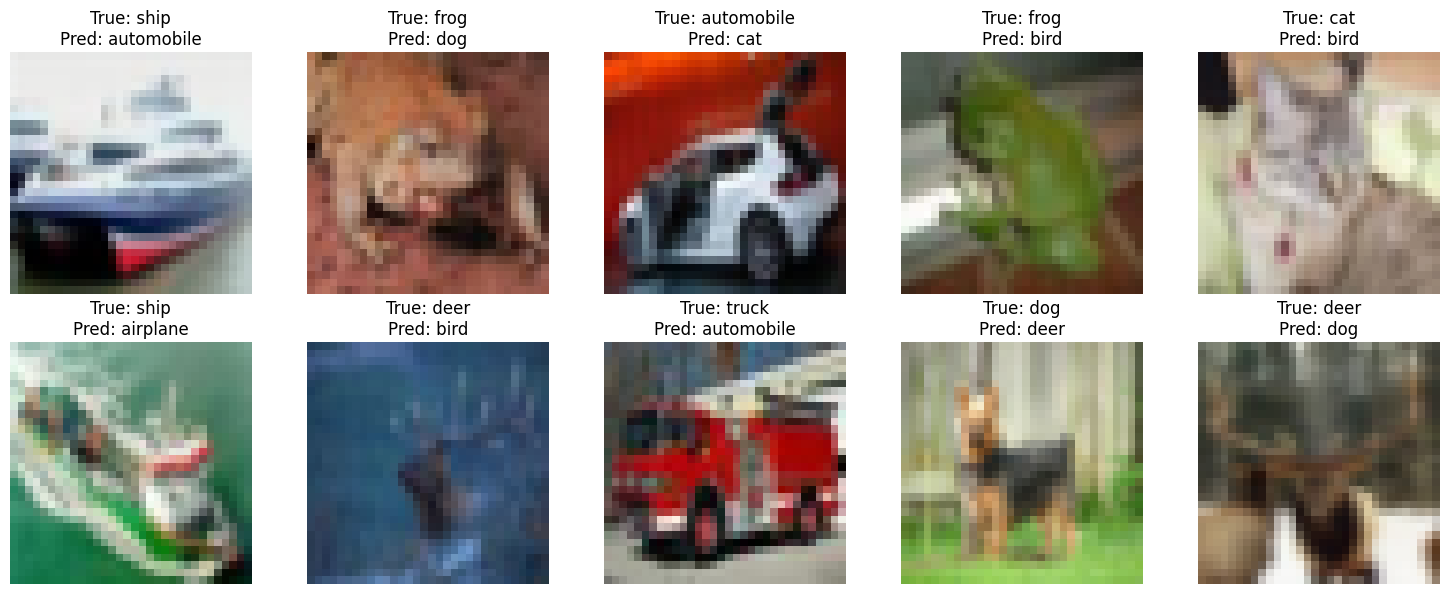


--- Proposed Improvements ---
1. Data-Level: Use oversampling/SMOTE or mixup techniques to artificially increase minority class samples.
2. Data-Level: More aggressive data augmentation (cutmix, autoaugment) on minority classes.
3. Architectural: Try specialized heads for minority classes or hierarchical classification.
4. Loss Function: Combine Focal Loss with Class-Balanced Loss margins, or utilize LDAM (Label-Distribution-Aware Margin loss).
5. Error Correlation: Classes with the fewest samples suffer from massive error rates due to lack of representation. Improving their representation will reduce bias.


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

print("--- Generating Predictions for Analysis ---")
model.eval() # Evaluating the CNN model
preds_list = []
labels_list = []
misclassified_imgs = []
misclassified_true = []
misclassified_pred = []

# Ensure tensors are moved to the same device as the current model weights
model_device = next(model.parameters()).device

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(model_device)
        labels = labels.to(model_device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        preds_list.extend(predicted.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())
        
        mask = predicted != labels
        if mask.any():
            misclassified_imgs.extend(inputs[mask].cpu().numpy())
            misclassified_true.extend(labels[mask].cpu().numpy())
            misclassified_pred.extend(predicted[mask].cpu().numpy())
        if len(misclassified_imgs) > 20: # cap memory usage
            pass

all_preds_numpy = np.array(preds_list)
all_labels_numpy = np.array(labels_list)

# 1. Identify which classes fail most frequently and Correlate errors with class imbalance ratios
print("\n--- Failure Analysis ---")
cm = confusion_matrix(all_labels_numpy, all_preds_numpy)
class_totals = cm.sum(axis=1)
class_correct = cm.diagonal()
class_errors = class_totals - class_correct
error_rates = np.zeros_like(class_totals, dtype=float)
np.divide(class_errors, class_totals, out=error_rates, where=class_totals!=0)

classes = test_dataset.classes
for i, cls in enumerate(classes):
    print(f"Class {cls} (Train samples: {class_counts[i]}): Error Rate = {error_rates[i]:.2%}")

# 2. Analyze confusion patterns
print("\n--- Confusion Patterns ---")
# Find highest off-diagonal values
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 50:
            print(f"{classes[i]} frequently misclassified as {classes[j]} ({cm[i, j]} times)")

# 3. Visualize misclassified samples
print("\n--- Visualizing Misclassified Samples ---")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    if i < len(misclassified_imgs):
        # Un-normalize the image
        img = misclassified_imgs[i].transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[misclassified_true[i]]}\nPred: {classes[misclassified_pred[i]]}")
        axes[i].axis('off')
plt.tight_layout()
plt.show()

# 4. Propose architectural or data-level improvements
print("\n--- Proposed Improvements ---")
print("1. Data-Level: Use oversampling/SMOTE or mixup techniques to artificially increase minority class samples.")
print("2. Data-Level: More aggressive data augmentation (cutmix, autoaugment) on minority classes.")
print("3. Architectural: Try specialized heads for minority classes or hierarchical classification.")
print("4. Loss Function: Combine Focal Loss with Class-Balanced Loss margins, or utilize LDAM (Label-Distribution-Aware Margin loss).")
print("5. Error Correlation: Classes with the fewest samples suffer from massive error rates due to lack of representation. Improving their representation will reduce bias.")
